# Customer Support Agent Evaluation

This notebook documents the reproducible baseline and improved-prompt evaluation for the 150-ticket customer-support routing dataset. It uses exact-match scoring and LangSmith ticket-level tracing. API keys are loaded from a local `.env` file and are never displayed.

**Controlled experiment:** the dataset, Nebius model, temperature, structured-output schema, evaluation logic, and trace structure remain fixed. Only one account-workflow disambiguation rule changes between prompt versions.

### How to use this submission

1. For evidence review, run the notebook as submitted; it loads the preserved outputs and requires no API keys.
2. For a fresh live evaluation, install `requirements.txt`, copy `.env.example` to `.env`, add your own keys, and set `RUN_LIVE = True`.
3. Live model outputs can vary slightly across provider/model revisions; the preserved CSVs and LangSmith IDs are the evidence for the reported run.

In [1]:
from pathlib import Path
import os
import pandas as pd
from dotenv import load_dotenv

def find_submission_dir():
    # Locate the submission folder when run from it, its notebook folder, or the repo.
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "submission", cwd.parent, cwd.parent / "submission", cwd.parent.parent]
    for candidate in candidates:
        if (candidate / "workbook/Customer Support Evaluation - Working Copy.xlsx").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the submission folder. Run this notebook from the submission or notebook folder."
    )

SUBMISSION_DIR = find_submission_dir()
WORKBOOK = SUBMISSION_DIR / "workbook/Customer Support Evaluation - Working Copy.xlsx"
RESULTS_DIR = SUBMISSION_DIR / "results"
load_dotenv(SUBMISSION_DIR / ".env")

print("Nebius key configured:", bool(os.getenv("NEBIUS_API_KEY")))
print("LangSmith key configured:", bool(os.getenv("LANGSMITH_API_KEY")))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))
print("Model:", os.getenv("NEBIUS_MODEL", "openai/gpt-oss-120b"))

Nebius key configured: False
LangSmith key configured: False
LangSmith project: None
Model: openai/gpt-oss-120b


## 1. Fixed evaluation dataset

In [2]:
raw = pd.read_excel(WORKBOOK, sheet_name="Step 1 · Tag failures", header=12)
tickets = raw[raw["#"].astype(str).str.fullmatch(r"t\d{3}")][
    ["#", "Ticket text", "True category"]
].rename(columns={"#": "id", "Ticket text": "ticket_text", "True category": "true_category"})
tickets = tickets.reset_index(drop=True)

assert len(tickets) == 150
assert tickets["id"].nunique() == 150
assert tickets["id"].tolist() == [f"t{i:03d}" for i in range(150)]

print("Fixed cases:", len(tickets))
print(tickets["true_category"].value_counts().reindex([
    "order_status", "refund_request", "product_issue", "account_help", "other"
]).to_string())
tickets.head(3)

Fixed cases: 150
true_category
order_status      24
refund_request    42
product_issue     24
account_help      30
other             30


,id,ticket_text,true_category
0,t000,"Hi, I ordered a blender 5 days ago and the tra...",order_status
1,t001,"Hey, placed an order for a blender 5 days back...",order_status
2,t002,"So I ordered a blender on Monday, supposedly i...",order_status


## 2. Baseline and improved prompts

In [3]:
BASELINE_PROMPT = """You are a triage system for an e-commerce support inbox.

Classify the customer's ticket into EXACTLY ONE of these categories:

- order_status: questions about where an order is, tracking, delivery ETA
- refund_request: the customer wants their money back
- product_issue: the item arrived broken, wrong, defective, or not as described
- account_help: login, password, address, payment method changes
- other: anything that doesn't fit the above (general questions, feedback, browsing)

Return only the category key.

Ticket:
{ticket_text}
"""

ACCOUNT_WORKFLOW_RULE = """Disambiguation rule for account workflows:
If the customer cannot complete an account-linked action because of repeated logout, an app or site crash, a rejected promo code at checkout, or a missing order record in account history, classify as account_help. Do not route only from surface words such as order, product, or discount."""

IMPROVED_PROMPT = BASELINE_PROMPT.replace(
    "\n\nReturn only the category key.",
    f"\n\n{ACCOUNT_WORKFLOW_RULE}\n\nReturn only the category key.",
)

assert ACCOUNT_WORKFLOW_RULE in IMPROVED_PROMPT
assert IMPROVED_PROMPT.replace(f"\n\n{ACCOUNT_WORKFLOW_RULE}", "") == BASELINE_PROMPT
print("Controlled prompt check passed: one rule added.")
print(ACCOUNT_WORKFLOW_RULE)

Controlled prompt check passed: one rule added.
Disambiguation rule for account workflows:
If the customer cannot complete an account-linked action because of repeated logout, an app or site crash, a rejected promo code at checkout, or a missing order record in account history, classify as account_help. Do not route only from surface words such as order, product, or discount.


## 3. Reproducible traced evaluation code

In [4]:
from typing import Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langsmith import traceable
from langsmith.run_helpers import get_current_run_tree
from time import perf_counter

class Classification(BaseModel):
    category: Literal["order_status", "refund_request", "product_issue", "account_help", "other"]
    reasoning: str = Field(description="One short sentence explaining the choice.")

def build_chain(prompt_text):
    model = ChatOpenAI(
        model=os.getenv("NEBIUS_MODEL", "openai/gpt-oss-120b"),
        api_key=os.environ["NEBIUS_API_KEY"],
        base_url=os.getenv("NEBIUS_BASE_URL", "https://api.tokenfactory.nebius.com/v1/"),
        temperature=0,
    ).with_structured_output(Classification, include_raw=True)
    return ChatPromptTemplate.from_template(prompt_text) | model

@traceable(name="customer-support-evaluation-ticket", run_type="chain")
def classify_ticket(chain, ticket_id, ticket_text, true_category, run_name, prompt_version):
    started = perf_counter()
    response = chain.invoke({"ticket_text": ticket_text})
    latency_s = perf_counter() - started
    result = response["parsed"]
    if result is None:
        raise ValueError(f"Structured output parsing failed for {ticket_id}: {response['parsing_error']}")
    raw = response["raw"]
    usage = getattr(raw, "usage_metadata", None) or {}
    correct = result.category == true_category
    run = get_current_run_tree()
    if run is not None:
        run.add_metadata({
            "evaluation_run": run_name,
            "prompt_version": prompt_version,
            "ticket_id": ticket_id,
            "true_category": true_category,
            "predicted_category": result.category,
            "correct": correct,
        })
    return {
        "predicted_category": result.category,
        "reasoning": result.reasoning,
        "correct": correct,
        "langsmith_run_id": str(run.id) if run is not None else "",
        "latency_s": latency_s,
        "input_tokens": usage.get("input_tokens"),
        "output_tokens": usage.get("output_tokens"),
        "total_tokens": usage.get("total_tokens"),
    }

def run_evaluation(prompt_text, run_name, prompt_version):
    chain = build_chain(prompt_text)
    rows = []
    for ticket in tickets.to_dict("records"):
        result = classify_ticket(
            chain, ticket["id"], ticket["ticket_text"], ticket["true_category"],
            run_name, prompt_version,
        )
        rows.append({
            **ticket, **result, "run_name": run_name, "prompt_version": prompt_version,
            "model": os.getenv("NEBIUS_MODEL", "openai/gpt-oss-120b"),
        })
    return pd.DataFrame(rows)

# Set RUN_LIVE=True only when intentionally creating a fresh pair of API runs.
# The submitted notebook loads the preserved outputs from the completed traced runs.
RUN_LIVE = False
print("Evaluation functions ready. RUN_LIVE =", RUN_LIVE)

Evaluation functions ready. RUN_LIVE = False


## 4. Load the completed traced runs

In [5]:
if RUN_LIVE:
    baseline = run_evaluation(BASELINE_PROMPT, "baseline", "instructor-original-v1")
    improved = run_evaluation(IMPROVED_PROMPT, "improved", "account-workflow-v2")
    baseline.to_csv(RESULTS_DIR / "baseline_results.csv", index=False)
    improved.to_csv(RESULTS_DIR / "improved_results.csv", index=False)
else:
    baseline = pd.read_csv(RESULTS_DIR / "baseline_results.csv")
    improved = pd.read_csv(RESULTS_DIR / "improved_results.csv")

for name, frame in [("baseline", baseline), ("improved", improved)]:
    assert len(frame) == 150
    assert frame["id"].tolist() == tickets["id"].tolist()
    assert frame["langsmith_run_id"].notna().all()
    assert frame["model"].nunique() == 1
    print(name, "rows:", len(frame), "unique trace IDs:", frame["langsmith_run_id"].nunique())

baseline rows: 150 unique trace IDs: 150
improved rows: 150 unique trace IDs: 150


## 5. Accuracy, latency, and token results

In [6]:
def summarize_live_operational(frame, run_name):
    return {
        "run": run_name,
        "cases": len(frame),
        "p50_latency_s": frame["latency_s"].quantile(0.50),
        "p95_latency_s": frame["latency_s"].quantile(0.95),
        "total_tokens": int(frame["total_tokens"].sum()),
        "avg_tokens": frame["total_tokens"].mean(),
        "source": "fresh notebook run",
    }

if RUN_LIVE:
    operational = pd.DataFrame([
        summarize_live_operational(baseline, "Baseline"),
        summarize_live_operational(improved, "Improved"),
    ])
    operational.to_csv(RESULTS_DIR / "classifier_operational_metrics_live.csv", index=False)
else:
    operational = pd.read_csv(RESULTS_DIR / "operational_metrics.csv")
    operational = operational[operational["evaluation"] == "classifier"].copy()

summary = pd.DataFrame([
    {"run": "Baseline", "correct": int(baseline["correct"].sum()), "cases": len(baseline), "accuracy": baseline["correct"].mean()},
    {"run": "Improved", "correct": int(improved["correct"].sum()), "cases": len(improved), "accuracy": improved["correct"].mean()},
]).merge(operational.drop(columns=["evaluation"], errors="ignore"), on=["run", "cases"])
summary["accuracy"] = summary["accuracy"].map(lambda value: f"{value:.1%}")
summary

,run,correct,cases,accuracy,judge_model,p50_latency_s,p95_latency_s,total_tokens,avg_tokens,source
0,Baseline,141,150,94.0%,NaN,0.603,0.936,45145,301.0,LangSmith completed traced run
1,Improved,149,150,99.3%,NaN,0.574,0.997,56161,374.4,LangSmith completed traced run


## 6. Fixes, regressions, and remaining failures

In [7]:
comparison = baseline.merge(
    improved[["id", "predicted_category", "reasoning", "correct", "langsmith_run_id"]],
    on="id", suffixes=("_baseline", "_improved"),
)
wins = comparison[(~comparison["correct_baseline"]) & comparison["correct_improved"]]
regressions = comparison[comparison["correct_baseline"] & (~comparison["correct_improved"])]
remaining = comparison[~comparison["correct_improved"]]

print("Accuracy delta:", f"{improved['correct'].mean() - baseline['correct'].mean():+.1%}")
print("Wins:", len(wins))
print("Regressions:", len(regressions))
print("Remaining failures:", len(remaining))

wins[["id", "true_category", "predicted_category_baseline", "predicted_category_improved"]]

Accuracy delta: +5.3%
Wins: 9
Regressions: 1
Remaining failures: 1


,id,true_category,predicted_category_baseline,predicted_category_improved
105,t105,account_help,other,account_help
106,t106,account_help,other,account_help
107,t107,account_help,other,account_help
114,t114,account_help,other,account_help
115,t115,account_help,other,account_help
116,t116,account_help,other,account_help
117,t117,account_help,order_status,account_help
118,t118,account_help,order_status,account_help
119,t119,account_help,order_status,account_help


In [8]:
regressions[[
    "id", "ticket_text", "true_category", "predicted_category_baseline",
    "predicted_category_improved", "reasoning_improved", "langsmith_run_id_improved"
]]

,id,ticket_text,true_category,predicted_category_baseline,predicted_category_improved,reasoning_improved,langsmith_run_id_improved
50,t050,Item went on sale right after I ordered. Do yo...,refund_request,refund_request,other,The ticket asks about price adjustments after ...,01a07894-e2e7-7052-9702-6df416728f61


## 7. LangSmith trace evidence

In [9]:
trace_examples = comparison[comparison["id"].isin(["t050", "t105", "t114", "t117"])][[
    "id", "true_category", "predicted_category_baseline", "predicted_category_improved",
    "langsmith_run_id_baseline", "langsmith_run_id_improved"
]].sort_values("id")
trace_examples

,id,true_category,predicted_category_baseline,predicted_category_improved,langsmith_run_id_baseline,langsmith_run_id_improved
50,t050,refund_request,refund_request,other,01a07861-e58c-7312-84cf-1b5c4d0442e2,01a07894-e2e7-7052-9702-6df416728f61
105,t105,account_help,other,account_help,01a07862-7f92-7622-93a9-f042272b577e,01a07895-78b9-7fb3-ba18-415f5867ff76
114,t114,account_help,other,account_help,01a07862-95f5-71b0-942c-56c3228f18d8,01a07895-90cf-7651-99c3-1c47ddcfa216
117,t117,account_help,order_status,account_help,01a07862-9e57-7821-ab3f-e03222f04215,01a07895-98e2-7f62-94b4-147c5a6e062b


### Screenshot pair: t105 before and after

Baseline: the original prompt classified the account-linked app crash as `other`.
Improved: the revised prompt explicitly applied the account-workflow rule and classified the same ticket as `account_help`.
The following executed cell embeds both full-resolution LangSmith screenshots in this notebook.

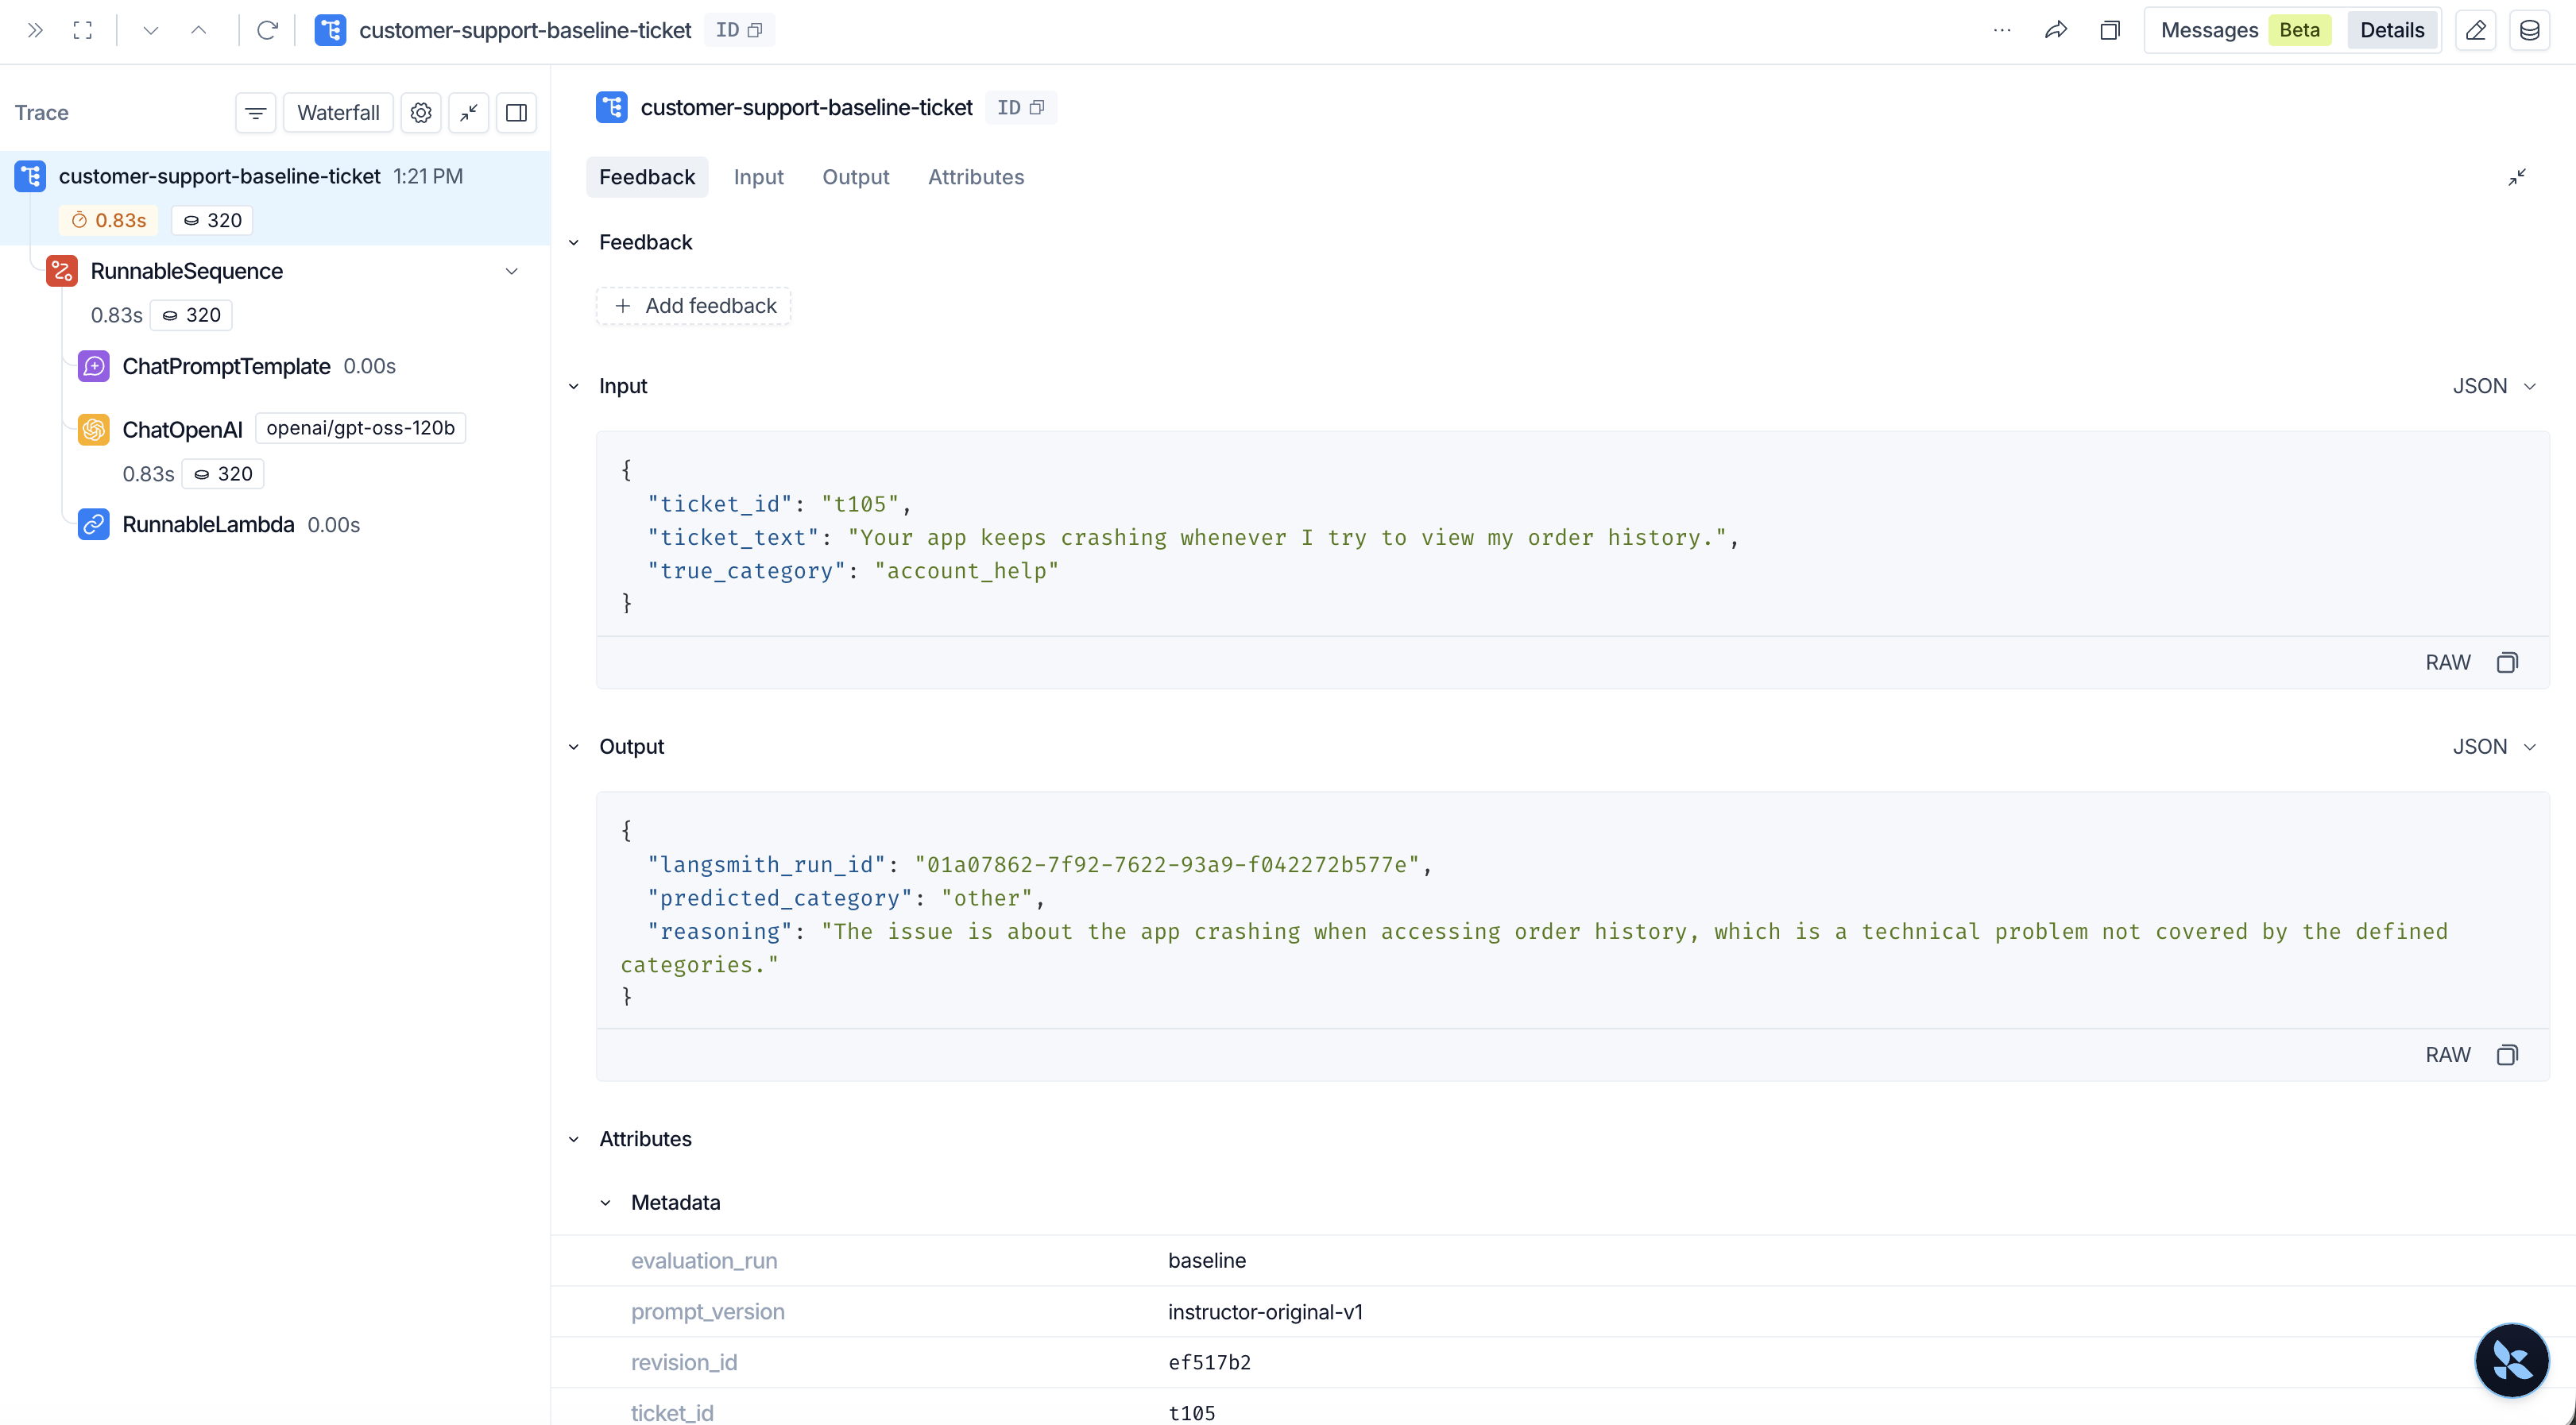

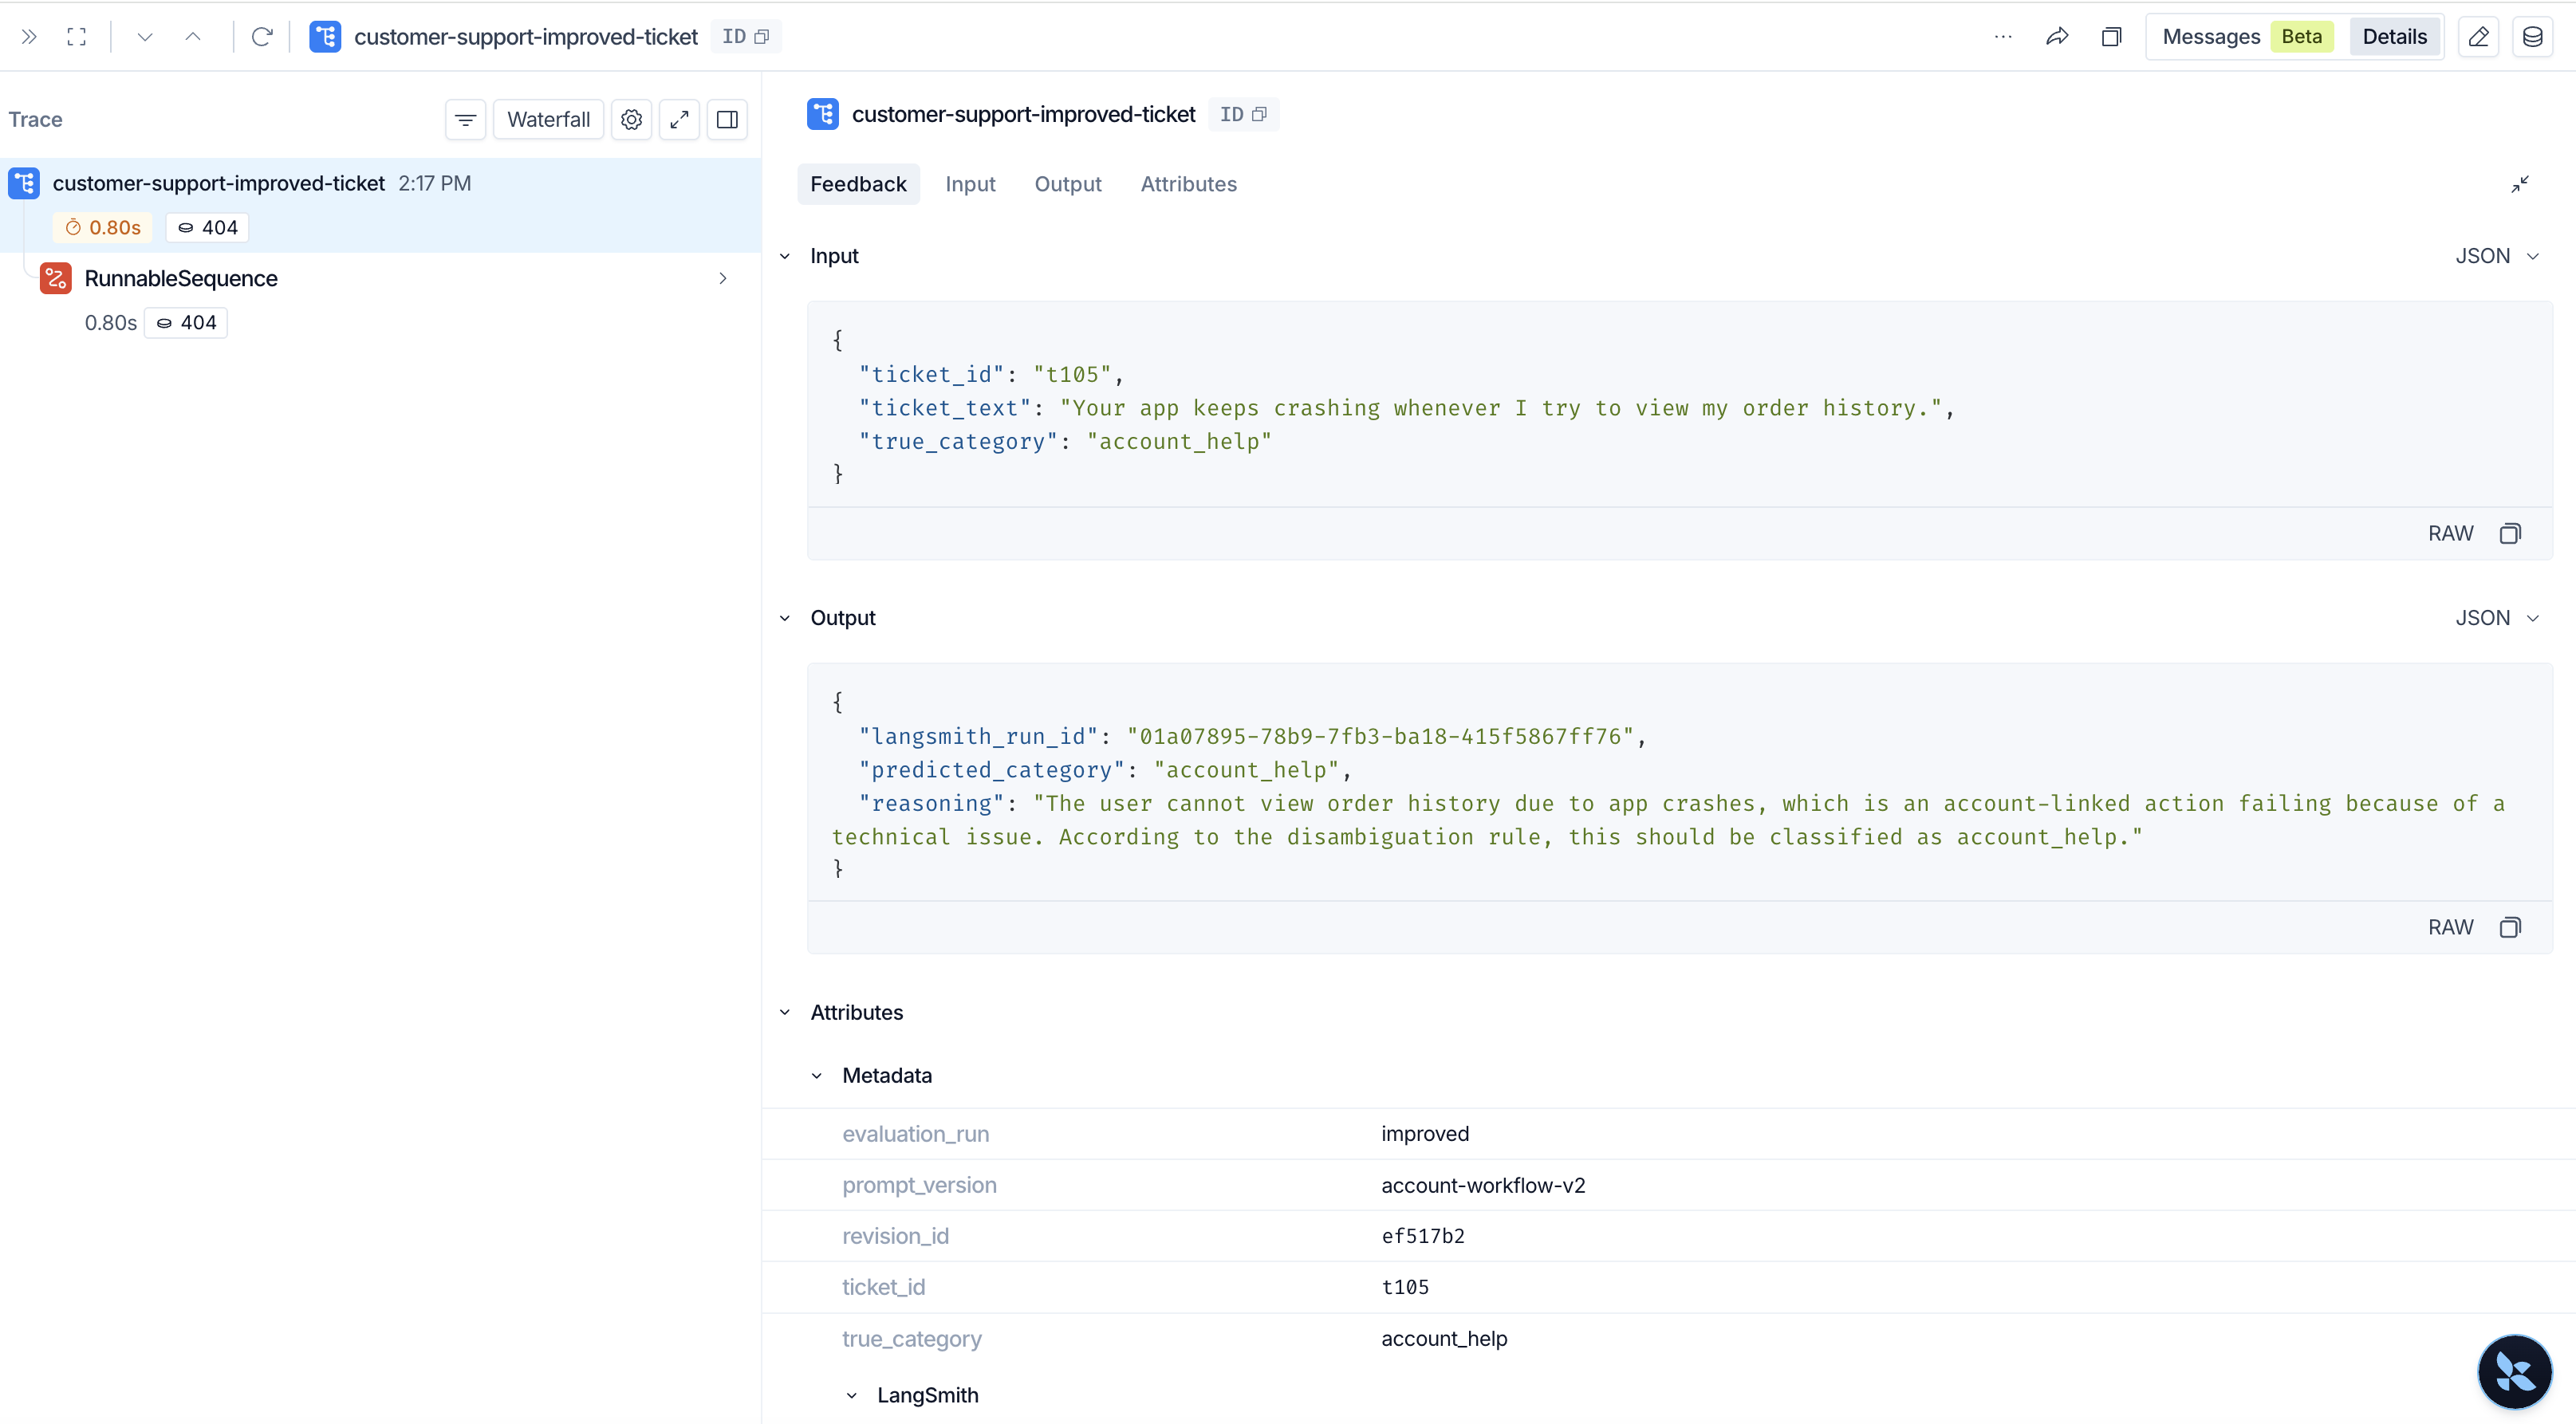

In [10]:
from IPython.display import Image, display
display(Image(filename=SUBMISSION_DIR / "langsmith-evidence/langsmith-t105-baseline-trace.png", width=1000))
display(Image(filename=SUBMISSION_DIR / "langsmith-evidence/langsmith-t105-improved-trace.png", width=1000))

## 8. Optional LLM-as-a-judge evaluation

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

JUDGE_PROMPT = (RESULTS_DIR / "llm_judge_prompt.txt").read_text()
judge_gpt = pd.read_csv(RESULTS_DIR / "llm_judge_openai__gpt_oss_120b.csv")
judge_qwen = pd.read_csv(RESULTS_DIR / "llm_judge_Qwen__Qwen3_235B_A22B_Instruct_2507.csv")

for name, frame in [("gpt-oss-120b", judge_gpt), ("Qwen3-235B", judge_qwen)]:
    assert len(frame) == 29
    assert int(frame["ground_truth"].sum()) == 9
    assert frame["langsmith_run_id"].notna().all()
    print(name, "agreement:", f"{frame['match'].mean():.1%}",
          "trace IDs:", frame["langsmith_run_id"].nunique())

print("\nBinary judge rubric:\n")
print(JUDGE_PROMPT)

gpt-oss-120b agreement: 100.0% trace IDs: 29
Qwen3-235B agreement: 100.0% trace IDs: 29

Binary judge rubric:

You are evaluating errors made by an e-commerce support-ticket classifier.

Target failure category: Account_Workflow_Missed

Definition:
The customer is unable to complete an account-linked workflow, but the classifier routes the ticket according to a surface topic instead of account_help. Qualifying workflows are repeated logout during checkout or payment, an app or site crash while accessing account features, a rejected promo code during checkout, or a completed purchase missing from the customer's account history.

Return TRUE only when BOTH conditions hold:
1. The user input describes one of those account-linked workflow failures.
2. The predicted intent is not account_help.

Return FALSE for delivery or tracking problems, refund or price-adjustment requests, subscription cancellation/refund requests, purchased-product defects, product-authenticity questions, shipping-cos

In [12]:
class JudgeDecision(BaseModel):
    label: bool = Field(description="TRUE when the error matches Account_Workflow_Missed, otherwise FALSE")
    reasoning: str = Field(description="One concise sentence citing the decisive workflow or exclusion rule")

def build_judge_chain(model_id):
    judge_model = ChatOpenAI(
        model=model_id,
        api_key=os.environ["NEBIUS_API_KEY"],
        base_url=os.getenv("NEBIUS_BASE_URL", "https://api.tokenfactory.nebius.com/v1/"),
        temperature=0,
    ).with_structured_output(JudgeDecision, include_raw=True)
    return ChatPromptTemplate.from_template(JUDGE_PROMPT) | judge_model

@traceable(name="account-workflow-judge", run_type="chain")
def judge_failure(judge_chain, ticket_id, user_input, predicted_intent, human_ground_truth, model_id):
    started = perf_counter()
    response = judge_chain.invoke({"user_input": user_input, "predicted_intent": predicted_intent})
    latency_s = perf_counter() - started
    decision = response["parsed"]
    if decision is None:
        raise ValueError(f"Judge output parsing failed for {ticket_id}: {response['parsing_error']}")
    raw = response["raw"]
    usage = getattr(raw, "usage_metadata", None) or {}
    match = bool(decision.label) == bool(human_ground_truth)
    run = get_current_run_tree()
    if run is not None:
        run.add_metadata({
            "evaluation_run": "llm-as-judge", "judge_model": model_id,
            "ticket_id": ticket_id, "human_ground_truth": bool(human_ground_truth),
            "judge_prediction": bool(decision.label), "match": match,
        })
    return {"judge_prediction": bool(decision.label), "judge_reasoning": decision.reasoning,
            "match": match, "langsmith_run_id": str(run.id) if run else "",
            "latency_s": latency_s, "input_tokens": usage.get("input_tokens"),
            "output_tokens": usage.get("output_tokens"), "total_tokens": usage.get("total_tokens")}

def run_judge_evaluation(model_id):
    judge_chain = build_judge_chain(model_id)
    source = judge_gpt[["id", "user_input", "predicted_intent", "ground_truth"]].copy()
    rows = []
    for row in source.to_dict("records"):
        result = judge_failure(
            judge_chain, row["id"], row["user_input"], row["predicted_intent"],
            row["ground_truth"], model_id,
        )
        rows.append({**row, **result, "judge_model": model_id})
    return pd.DataFrame(rows)

RUN_JUDGE_LIVE = False
print("Judge rerun function ready. RUN_JUDGE_LIVE =", RUN_JUDGE_LIVE)

Judge rerun function ready. RUN_JUDGE_LIVE = False


## 9. Judge agreement and model comparison

In [13]:
if RUN_JUDGE_LIVE:
    live_judges = []
    for model_id in ["openai/gpt-oss-120b", "Qwen/Qwen3-235B-A22B-Instruct-2507"]:
        frame = run_judge_evaluation(model_id)
        safe_name = model_id.replace("/", "__")
        frame.to_csv(RESULTS_DIR / f"llm_judge_live_{safe_name}.csv", index=False)
        live_judges.append((model_id, frame))
    judge_comparison = pd.DataFrame([{
        "judge_model": model_id, "agreement": frame["match"].mean(),
        "correct": int(frame["match"].sum()), "cases": len(frame),
        "p50_latency_s": frame["latency_s"].quantile(0.50),
        "p95_latency_s": frame["latency_s"].quantile(0.95),
        "total_tokens": int(frame["total_tokens"].sum()),
        "avg_tokens": frame["total_tokens"].mean(),
    } for model_id, frame in live_judges])
else:
    judge_operational = pd.read_csv(RESULTS_DIR / "operational_metrics.csv")
    judge_operational = judge_operational[judge_operational["evaluation"] == "llm_judge"]
    judge_comparison = pd.DataFrame([
        {"judge_model": "openai/gpt-oss-120b", "agreement": judge_gpt["match"].mean(),
         "correct": int(judge_gpt["match"].sum()), "cases": 29},
        {"judge_model": "Qwen/Qwen3-235B-A22B-Instruct-2507", "agreement": judge_qwen["match"].mean(),
         "correct": int(judge_qwen["match"].sum()), "cases": 29},
    ]).merge(judge_operational.drop(columns=["evaluation", "run"], errors="ignore"),
             on=["judge_model", "cases"])
judge_comparison["agreement"] = judge_comparison["agreement"].map(lambda value: f"{value:.1%}")
judge_comparison

,judge_model,agreement,correct,cases,p50_latency_s,p95_latency_s,total_tokens,avg_tokens,source
0,openai/gpt-oss-120b,100.0%,29,29,0.772,1.119,13945,480.9,LangSmith completed traced run
1,Qwen/Qwen3-235B-A22B-Instruct-2507,100.0%,29,29,0.927,1.283,10046,346.4,LangSmith completed traced run


In [14]:
print("Selected judge: openai/gpt-oss-120b")
print("Selection reason: tied at 100% agreement, lower latency, and more concise reasoning.")
print("Qwen tradeoff: fewer tokens, but slower and more verbose.")
print("Mismatches for selected judge:", int((~judge_gpt["match"]).sum()))
print("\nConfusion matrix [FALSE, TRUE]:")
print(confusion_matrix(judge_gpt["ground_truth"], judge_gpt["judge_prediction"], labels=[False, True]))
print("\nClassification report:")
print(classification_report(judge_gpt["ground_truth"], judge_gpt["judge_prediction"],
                            labels=[False, True], target_names=["FALSE", "TRUE"], zero_division=0))

judge_gpt[judge_gpt["id"].isin(["t024", "t103"])][[
    "id", "user_input", "predicted_intent", "ground_truth", "judge_prediction",
    "judge_reasoning", "langsmith_run_id"
]]

Selected judge: openai/gpt-oss-120b
Selection reason: tied at 100% agreement, lower latency, and more concise reasoning.
Qwen tradeoff: fewer tokens, but slower and more verbose.
Mismatches for selected judge: 0

Confusion matrix [FALSE, TRUE]:
[[20  0]
 [ 0  9]]

Classification report:
              precision    recall  f1-score   support

       FALSE       1.00      1.00      1.00        20
        TRUE       1.00      1.00      1.00         9

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



,id,user_input,predicted_intent,ground_truth,judge_prediction,judge_reasoning,langsmith_run_id
6,t024,The carrier marked it delivered but it shows t...,account_help,False,False,The user is reporting a delivery issue (wrong ...,01a078c6-ff5c-7241-bef3-4b8f718cbe2d
15,t103,Site logs me out every time I try to pay.,product_issue,True,True,The user reports being logged out repeatedly d...,01a078c7-1d3a-70f2-ac57-b1c7f28c2a9d


## 10. Interpretation and next evaluation cycle

The focused prompt change corrected all nine targeted account-workflow failures and increased accuracy from **94.0% to 99.3%**. It produced one regression, `t050`, involving a post-purchase price adjustment. Token use rose by **24.4%**, while p95 latency remained below the 1.5-second pass bar.

The next controlled experiment should explicitly map post-purchase price adjustments to `refund_request`, then rerun the same dataset with regression checks for pre-purchase discount questions and promo-code failures. That second change is intentionally excluded from the current experiment so the measured improvement remains attributable to one prompt intervention.